In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Input
from tensorflow.keras.optimizers import Adam

In [2]:
data = pd.read_csv("data.csv", encoding="latin1", low_memory=False)

# column name check kar lena (NO2 ya no2)
x = data["no2"].dropna().values

In [3]:
r = 102303514

a_r = 0.5 * (r % 7)
b_r = 0.3 * ((r % 5) + 1)

z = x + a_r * np.sin(b_r * x)

print("a_r:", a_r, "b_r:", b_r)

z_mean = np.mean(z)
z_std = np.std(z)

z_scaled = (z - z_mean) / (3 * z_std)
z_scaled = z_scaled.reshape(-1, 1)

a_r: 2.5 b_r: 1.5


In [4]:
# GENERATOR
def generator_net():
    return Sequential([
        Input(shape=(1,)),
        Dense(16),
        LeakyReLU(0.2),
        Dense(16),
        LeakyReLU(0.2),
        Dense(1, activation='tanh')
    ])


# DISCRIMINATOR
def discriminator_net():
    return Sequential([
        Input(shape=(1,)),
        Dense(16),
        LeakyReLU(0.2),
        Dense(16),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])

In [5]:
G = generator_net()
D = discriminator_net()

D.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0001, beta_1=0.5),
    metrics=['accuracy']
)

D.trainable = False

GAN = Sequential([G, D])

GAN.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0001, beta_1=0.5)
)


In [6]:
# TRAINING
epochs = 1500
batch_size = 64

print("Training started...")

for epoch in range(epochs):

    # Real samples
    idx = np.random.randint(0, z_scaled.shape[0], batch_size)
    real = z_scaled[idx]

    # Fake samples
    noise = np.random.normal(0, 1, (batch_size, 1))
    fake = G.predict(noise, verbose=0)

    # Labels
    real_y = np.ones((batch_size, 1))
    fake_y = np.zeros((batch_size, 1))

    # Train Discriminator
    d_loss_real = D.train_on_batch(real, real_y)
    d_loss_fake = D.train_on_batch(fake, fake_y)
    d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, 1))
    g_loss = GAN.train_on_batch(noise, real_y)

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")


Training started...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.6796 | G Loss: 0.6876
Epoch 300 | D Loss: 0.7015 | G Loss: 0.6557
Epoch 600 | D Loss: 0.7285 | G Loss: 0.6098
Epoch 900 | D Loss: 0.7492 | G Loss: 0.5777
Epoch 1200 | D Loss: 0.7635 | G Loss: 0.5563


In [7]:
# GENERATE DATA
noise = np.random.normal(0, 1, (5000, 1))
gen_scaled = G.predict(noise, verbose=0)

# Reverse scaling
generated_z = gen_scaled * (3 * z_std) + z_mean
real_z = z_scaled * (3 * z_std) + z_mean

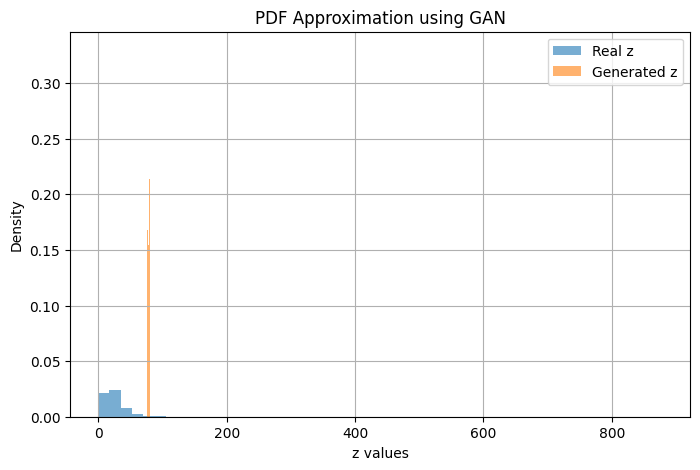

In [9]:
# HISTOGRAM PDF
low = np.percentile(real_z, 1)
high = np.percentile(real_z, 99)

plt.figure(figsize=(8,5))

plt.hist(real_z.flatten(), bins=50, density=True, alpha=0.6, label="Real z")
plt.hist(generated_z.flatten(), bins=50, density=True, alpha=0.6, label="Generated z")

plt.xlabel("z values")
plt.ylabel("Density")
plt.title("PDF Approximation using GAN")
plt.legend()
plt.grid(True)

plt.show()
